In [2]:
import pandas as pd

co2_df = pd.read_csv("/home/onyxia/work/Stat-App-Montee-des-oceans/co2_trend.csv")
co2_df.rename(columns={'year_month': 'time'}, inplace=True)
co2_df['time'] = pd.to_datetime(co2_df['time'], errors='coerce')  # 'coerce' pour gérer les valeurs invalides

sea_level_df = pd.read_csv("/home/onyxia/work/Stat-App-Montee-des-oceans/my_data_folder/sea_level_folder/sea_level_monthly/sea_level_monthly.csv", parse_dates=['time'])
co2_df.head()

,time,co2_trend
0,2007-04-01,384.565750
1,2007-05-01,384.752639
2,2007-06-01,385.115639
3,2007-07-01,385.504535
4,2007-08-01,385.725826


In [3]:
print("CO2 dates:", co2_df['time'].min(), "→", co2_df['time'].max())
print("Sea level dates:", sea_level_df['time'].min(), "→", sea_level_df['time'].max())


CO2 dates: 2007-04-01 00:00:00 → 2024-05-01 00:00:00
Sea level dates: 1993-01-16 00:00:00 → 2023-06-04 00:00:00


In [4]:
co2_df['year'] = co2_df['time'].dt.year
co2_df['month'] = co2_df['time'].dt.month

sea_level_df['year'] = sea_level_df['time'].dt.year
sea_level_df['month'] = sea_level_df['time'].dt.month

In [5]:
co2_monthly = co2_df.groupby(['year', 'month']).mean().reset_index()
sea_level_monthly = sea_level_df.groupby(['year', 'month']).mean().reset_index()


In [6]:
merged_df = pd.merge(co2_monthly, sea_level_monthly, on=['year', 'month'], how='inner')
merged_df.head()


,year,month,time_x,co2_trend,time_y,MSL_filtered_GIA_TPA_corrected_adjusted,trend_MSL_filtered_GIA_TPA_corrected_adjusted
0,2007,4,2007-04-01,384.565750,2007-04-15 12:00:00,5.274960,5.437881
1,2007,5,2007-05-01,384.752639,2007-05-16 00:00:00,5.245975,5.458814
2,2007,6,2007-06-01,385.115639,2007-06-15 12:00:00,5.301428,5.479757
3,2007,7,2007-07-01,385.504535,2007-07-16 00:00:00,5.182237,5.500710
4,2007,8,2007-08-01,385.725826,2007-08-16 00:00:00,4.542826,5.522017


Pente (coefficient): 0.1017
Ordonnée à l'origine: -33.3505
Score R²: 0.2526


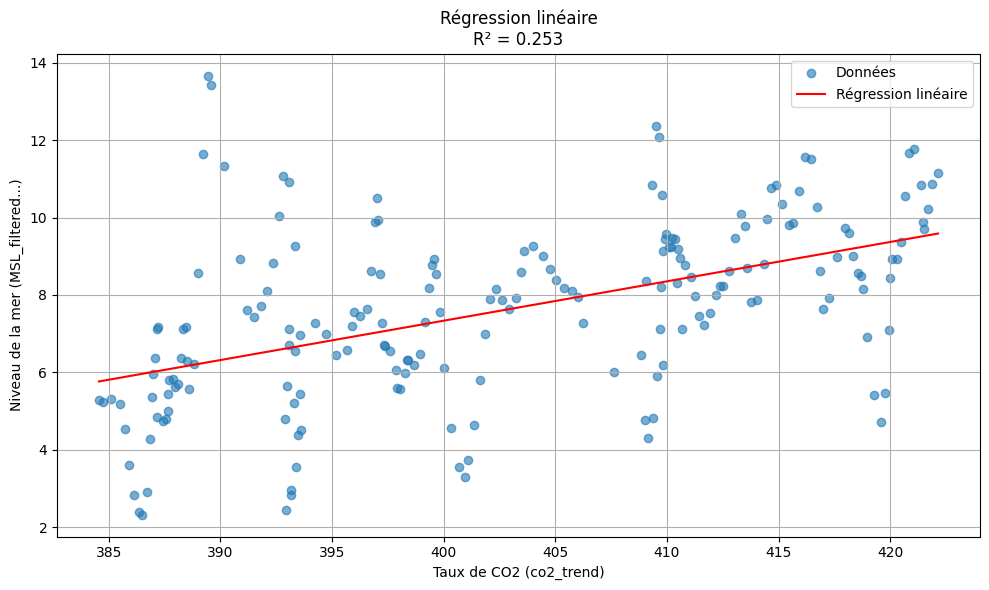

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Préparation des données
df = merged_df[['co2_trend', 'MSL_filtered_GIA_TPA_corrected_adjusted']].dropna()
X = df[['co2_trend']].values
y = df['MSL_filtered_GIA_TPA_corrected_adjusted'].values

# Modèle
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Statistiques
coef = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

print(f"Pente (coefficient): {coef:.4f}")
print(f"Ordonnée à l'origine: {intercept:.4f}")
print(f"Score R²: {r2:.4f}")

# Graphique
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Données')
plt.plot(X, y_pred, color='red', label='Régression linéaire')
plt.xlabel('Taux de CO2 (co2_trend)')
plt.ylabel('Niveau de la mer (MSL_filtered...)')
plt.title(f"Régression linéaire\nR² = {r2:.3f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
